# Compute Engine Tutorial

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import climadace as ce

In [4]:
hazard = ce.open_dataarray("data/hazard/Europe_RP100_filled_depth.tif")
hazard

<xarray.DataArray 'band_data' (band: 1, y: 51992, x: 110162)> Size: 23GB
dask.array<open_dataset-band_data, shape=(1, 51992, 110162), dtype=float32, chunksize=(1, 5632, 5632), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 881kB -24.54 -24.54 -24.54 ... 67.26 67.26 67.26
  * y            (y) float64 416kB 71.13 71.13 71.13 71.13 ... 27.81 27.81 27.81
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:  Area

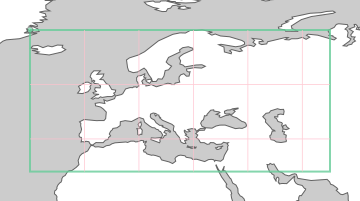

In [5]:
hazard.odc.geobox

In [6]:
exposure = ce.open_dataarray("data/exposure/deu_ppp_2000_1km_Aggregated_UNadj.tif")
exposure

<xarray.DataArray 'band_data' (band: 1, y: 934, x: 1100)> Size: 4MB
dask.array<open_dataset-band_data, shape=(1, 934, 1100), dtype=float32, chunksize=(1, 934, 1100), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    spatial_ref  int64 8B ...
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  3301.6967773438
    STATISTICS_MEAN:     122.93104760496
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   266.87357580513

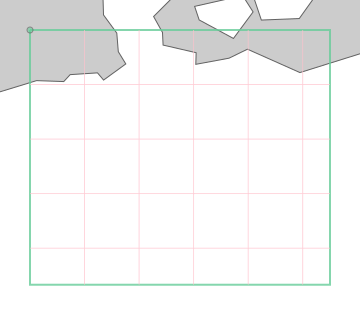

In [7]:
exposure.odc.geobox

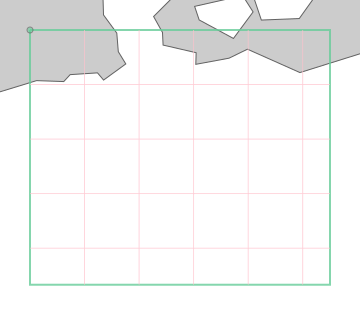

In [8]:
hazard, exposure = ce.align(hazard, exposure)
hazard.odc.geobox

In [9]:
import numpy as np


def sigmoid(x, threshold=0.1, half_point=1.0, exponent=3, scale=1.0):
    foo = (x - threshold) / (half_point - threshold)
    return np.maximum(scale * foo**exponent / (1 + foo**exponent), 0.0)

In [10]:
# REGISTRY = ce.ImpactFunctionRegistry()
# REGISTRY.allow_overwrite = True

In [11]:
# TODO: Write interpolated impact function
@ce.impact_function(interp_at=np.linspace(0, 5, 50), name="RF1")
def my_func(x):
    return sigmoid(x, threshold=0.5)

/var/folders/fj/w4lbl0pd7l1gcvt664mkfnh00000gq/T/ipykernel_11278/1723656814.py:6: RuntimeWarning: divide by zero encountered in divide
  return np.maximum(scale * foo**exponent / (1 + foo**exponent), 0.0)


In [12]:
# TODO: Add impf_map definition

engine = ce.Engine(
    hazard=hazard,
    exposure=exposure,
    impf_map={ce.FuncType.leaf: "RF1"},
)
impact = engine.impact()
impact

<xarray.DataTree>
Group: /
    Dimensions:      (band: 1, x: 1100, y: 934)
    Coordinates:
      * band         (band) int64 8B 1
      * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
      * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
        spatial_ref  int64 8B 0
    Data variables:
        band_data    (band, y, x) float64 8MB dask.array<chunksize=(1, 934, 1100), meta=np.ndarray>

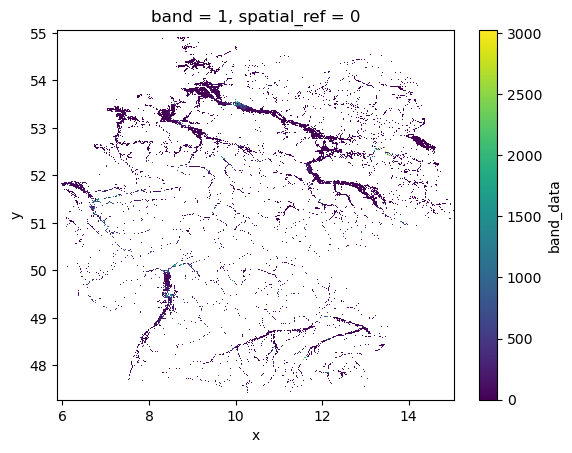

In [13]:
impact["band_data"].plot()

In [14]:
at_event = engine.aggregate(ce.at_event).compute()
at_event

<xarray.DataTree>
Group: /
    Dimensions:      (band: 1)
    Coordinates:
      * band         (band) int64 8B 1
        spatial_ref  int64 8B 0
    Data variables:
        band_data    (band) float64 8B 5.229e+06

## Multi-dim datasets

In [15]:
import xarray as xr

RP = [10, 50, 100]
hazard = xr.concat(
    [ce.open_dataarray(f"data/hazard/Europe_RP{rp}_filled_depth.tif") for rp in RP],
    dim=xr.DataArray(RP, dims=("return_period")),
)
hazard

<xarray.DataArray 'band_data' (return_period: 3, band: 1, y: 51992, x: 110162)> Size: 69GB
dask.array<concatenate, shape=(3, 1, 51992, 110162), dtype=float32, chunksize=(1, 1, 5632, 5632), chunktype=numpy.ndarray>
Coordinates:
  * band           (band) int64 8B 1
  * x              (x) float64 881kB -24.54 -24.54 -24.54 ... 67.26 67.26 67.26
  * y              (y) float64 416kB 71.13 71.13 71.13 ... 27.81 27.81 27.81
    spatial_ref    int64 8B 0
  * return_period  (return_period) int64 24B 10 50 100
Attributes:
    AREA_OR_POINT:  Area

In [16]:
YEAR = [2000, 2001]
exposure = xr.concat(
    [
        ce.open_dataarray(f"data/exposure/deu_ppp_{year}_1km_Aggregated_UNadj.tif")
        for year in YEAR
    ],
    dim=xr.DataArray(YEAR, dims=("year")),
)
exposure

<xarray.DataArray 'band_data' (year: 2, band: 1, y: 934, x: 1100)> Size: 8MB
dask.array<concatenate, shape=(2, 1, 934, 1100), dtype=float32, chunksize=(1, 1, 934, 1100), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
  * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
    spatial_ref  int64 8B 0
  * year         (year) int64 16B 2000 2001
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  3301.6967773438
    STATISTICS_MEAN:     122.93104760496
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   266.87357580513

In [17]:
hazard, exposure = ce.align(hazard, exposure)
engine = ce.Engine(
    hazard=hazard,
    exposure=exposure,
    impf_map={ce.FuncType.leaf: "RF1"},
)
impact = engine.impact()
impact

<xarray.DataTree>
Group: /
    Dimensions:        (band: 1, x: 1100, y: 934, return_period: 3, year: 2)
    Coordinates:
      * band           (band) int64 8B 1
      * x              (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
      * y              (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
      * return_period  (return_period) int64 24B 10 50 100
        spatial_ref    int64 8B 0
      * year           (year) int64 16B 2000 2001
    Data variables:
        band_data      (return_period, band, y, x, year) float64 49MB dask.array<chunksize=(3, 1, 934, 1100, 1), meta=np.ndarray>

In [18]:
diff = impact.sel(return_period=100, year=2000) - impact.sel(
    return_period=10, year=2000
)
diff

<xarray.DataTree>
Group: /
    Dimensions:      (band: 1, x: 1100, y: 934)
    Coordinates:
      * band         (band) int64 8B 1
      * x            (x) float64 9kB 5.878 5.886 5.895 5.903 ... 15.02 15.03 15.04
      * y            (y) float64 7kB 55.05 55.05 55.04 55.03 ... 47.3 47.29 47.28
        spatial_ref  int64 8B 0
        year         int64 8B 2000
    Data variables:
        band_data    (band, y, x) float64 8MB dask.array<chunksize=(1, 934, 1100), meta=np.ndarray>

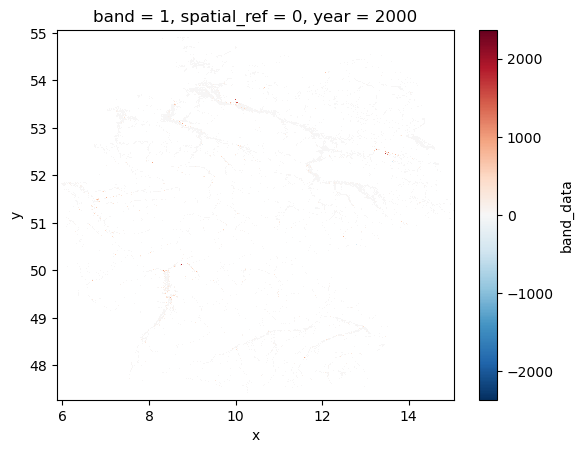

In [19]:
diff["band_data"].plot()

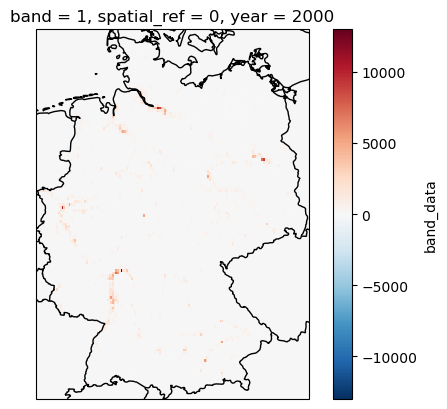

In [20]:
# TODO: Coarsen by 7
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Mercator()})

diff["band_data"].coarsen({"x": 7, "y": 7}, "pad").sum().plot(ax=ax, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS)
ax.coastlines("10m")

In [21]:
# TODO: Average annual impact
average_impact = engine.aggregate(
    lambda x: ce.average_event_impact(x, "return_period", 1.0 / impact["return_period"])
).compute()
average_impact

<xarray.DataTree>
Group: /
    Dimensions:      (band: 1, year: 2)
    Coordinates:
      * band         (band) int64 8B 1
        spatial_ref  int64 8B 0
      * year         (year) int64 16B 2000 2001
    Data variables:
        band_data    (band, year) float64 16B 4.014e+06 3.94e+06

## GHSL

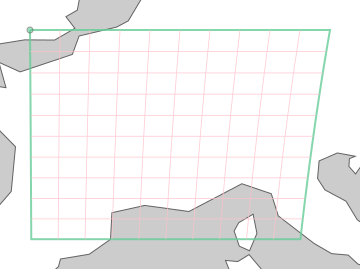

In [22]:
GHSL_YEAR = [2000, 2010, 2025]

hazard = xr.concat(
    [ce.open_dataarray(f"data/hazard/Europe_RP{rp}_filled_depth.tif") for rp in RP],
    dim=xr.DataArray(RP, dims=("return_period")),
)
exposure = ce.open_dataarray(
    "data/exposure/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif"
)
exposure.odc.geobox

In [23]:
hazard, exposure = ce.align(hazard, exposure)

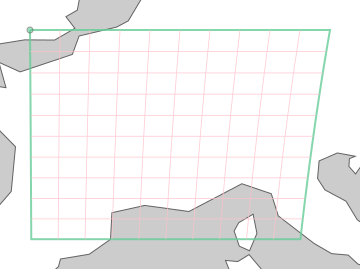

In [24]:
hazard.odc.geobox

In [25]:
import cartopy
import geopandas as gpd

ne = cartopy.io.shapereader.natural_earth(
    resolution="10m", category="cultural", name="admin_1_states_provinces"
)
ne_gdf = gpd.read_file(ne)
ne_gdf[ne_gdf["adm0_a3"] == "CHE"].head()

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
389,Admin-1 scale rank,9,CHE-165,165,CH-VS,None,CH,1,Valais,Vallais|Vallese|Wallis,...,None,None,None,None,None,None,None,None,None,"POLYGON ((7.84962 45.93971, 7.84839 45.93808, ..."
391,Admin-1 scale rank,9,CHE-168,168,CH-TI,None,CH,1,Ticino,Tesino|Tessin,...,None,None,None,None,None,None,None,None,None,"POLYGON ((8.72897 46.10824, 8.72389 46.10954, ..."
394,Admin-1 scale rank,9,CHE-170,170,CH-GR,None,CH,1,Graubünden,Graubünden|Grigioni|Grischun|Grisons,...,None,None,None,None,None,None,None,None,None,"POLYGON ((9.22483 46.23119, 9.21575 46.22106, ..."
765,Admin-1 scale rank,9,CHE-171,171,CH-SH,None,CH,1,Schaffhausen,Schaffhouse|Schaffusa|Sciaffusa,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((8.55822 47.80117, 8.58312 47.8..."
766,Admin-1 scale rank,9,CHE-174,174,CH-TG,None,CH,1,Thurgau,Thurgovie|Turgovia|Turg¢via,...,None,None,None,None,None,None,None,None,None,"POLYGON ((8.85194 47.67128, 8.85267 47.67079, ..."


In [38]:
exp_split = ce.split_from_geo(
    exposure,
    ne_gdf[ne_gdf["adm0_a3"].isin(["CHE", "DEU", "FRA"])],
    groupby_kws={"by": "adm0_a3"},
    mask_kws={"dropna": True},
)
exp_split

{'all_touched': False, 'dropna': True}


<xarray.DataTree>
Group: /
├── Group: /CHE
│       Dimensions:      (band: 1, y: 2122, x: 3558)
│       Coordinates:
│         * band         (band) int64 8B 1
│         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│           spatial_ref  int64 8B ...
│       Data variables:
│           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│       Attributes:
│           AREA_OR_POINT:  Area
├── Group: /DEU
│       Dimensions:      (band: 1, y: 4152, x: 5200)
│       Coordinates:
│         * band         (band) int64 8B 1
│         * x            (x) float64 42kB 4.39e+05 4.392e+05 ... 9.588e+05 9.59e+05
│         * y            (y) float64 33kB 6e+06 6e+06 6e+06 ... 5.585e+06 5.585e+06
│           spatial_ref  int64 8B ...
│       Data variables:
│           band_data    (band, y, x) float64 173MB dask.array<chunksize=(1, 3333, 3333), meta=np.ndarray>
│       Attributes:
│           AREA_OR_POINT:  Area
└── Group: /FRA
        Dimensions:      (band: 1, y: 9869, x: 7588)
        Coordinates:
          * band         (band) int64 8B 1
          * x            (x) float64 61kB -4.095e+04 -4.085e+04 ... 7.952e+05 7.954e+05
          * y            (y) float64 79kB 5.987e+06 5.987e+06 5.987e+06 ... 5e+06 5e+06
            spatial_ref  int64 8B ...
        Data variables:
            band_data    (band, y, x) float64 599MB dask.array<chunksize=(1, 3333, 3333), meta=np.ndarray>
        Attributes:
            AREA_OR_POINT:  Area

In [39]:
ce.split_from_geo(
    exp_split["/CHE"],
    ne_gdf[ne_gdf["adm0_a3"] == "CHE"],
    groupby_kws={"by": "iso_3166_2"},
    # mask_kws={"dropna": True},
    inplace=True,
)
exp_split

{'all_touched': False}


<xarray.DataTree>
Group: /
├── Group: /CHE
│   ├── Group: /CHE/CH-AG
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   ├── Group: /CHE/CH-AI
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   ├── Group: /CHE/CH-AR
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   ...
│   ├── Group: /CHE/CH-VS
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   ├── Group: /CHE/CH-ZG
│   │       Dimensions:      (band: 1, y: 2122, x: 3558)
│   │       Coordinates:
│   │         * band         (band) int64 8B 1
│   │         * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│   │         * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│   │           spatial_ref  int64 8B ...
│   │       Data variables:
│   │           band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│   │       Attributes:
│   │           AREA_OR_POINT:  Area
│   └── Group: /CHE/CH-ZH
│           Dimensions:      (band: 1, y: 2122, x: 3558)
│           Coordinates:
│             * band         (band) int64 8B 1
│             * x            (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
│             * y            (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
│               spatial_ref  int64 8B ...
│           Data variables:
│               band_data    (band, y, x) float64 60MB dask.array<chunksize=(1, 2122, 3333), meta=np.ndarray>
│           Attributes:
│               AREA_OR_POINT:  Area
├── Group: /DEU
│       Dimensions:      (band: 1, y: 4152, x: 5200)
│       Coordinates:
│         * band         (band) int64 8B 1
│         * x            (x) float64 42kB 4.39e+05 4.392e+05 ... 9.588e+05 9.59e+05
│         * y            (y) float64 33kB 6e+06 6e+06 6e+06 ... 5.585e+06 5.585e+06
│           spatial_ref  int64 8B ...
│       Data variables:
│           band_data    (band, y, x) float64 173MB dask.array<chunksize=(1, 3333, 3333), meta=np.ndarray>
│       Attributes:
│  

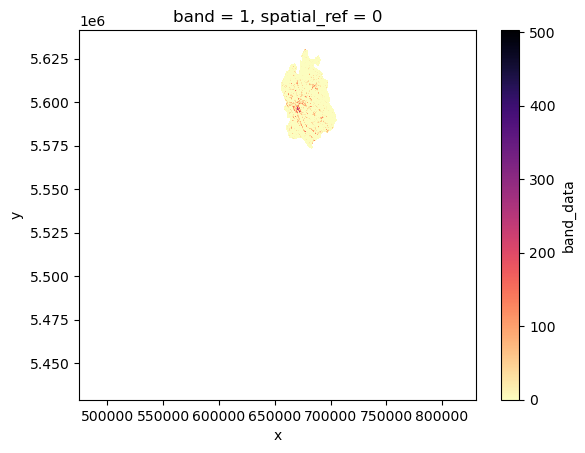

In [31]:
# TODO: Select ZH
exp_split["CHE/CH-ZH"]["band_data"].plot(cmap="magma_r")

In [40]:
engine = ce.Engine(
    hazard=hazard,
    exposure=exp_split,
    impf_map={
        "CHE": lambda inundation: xr.where(inundation > 0.5, 1.0, np.nan),
        "CH-ZH": "RF1",
        ce.FuncType.leaf: sigmoid,
    },
)
impact = engine.impact(compute=False)
impact

<xarray.DataTree>
Group: /
├── Group: /DEU
│       Dimensions:        (band: 1, return_period: 3, y: 4152, x: 5200)
│       Coordinates:
│         * band           (band) int64 8B 1
│         * return_period  (return_period) int64 24B 10 50 100
│         * y              (y) float64 33kB 6e+06 6e+06 6e+06 ... 5.585e+06 5.585e+06
│         * x              (x) float64 42kB 4.39e+05 4.392e+05 ... 9.588e+05 9.59e+05
│           spatial_ref    int32 4B 0
│       Data variables:
│           band_data      (return_period, band, y, x) float64 518MB dask.array<chunksize=(1, 1, 3333, 3333), meta=np.ndarray>
├── Group: /FRA
│       Dimensions:        (band: 1, return_period: 3, y: 9869, x: 7588)
│       Coordinates:
│         * band           (band) int64 8B 1
│         * return_period  (return_period) int64 24B 10 50 100
│         * y              (y) float64 79kB 5.987e+06 5.987e+06 ... 5e+06 5e+06
│         * x              (x) float64 61kB -4.095e+04 -4.085e+04 ... 7.954e+05
│           spatial_ref    int32 4B 0
│       Data variables:
│           band_data      (return_period, band, y, x) float64 2GB dask.array<chunksize=(1, 1, 3333, 3333), meta=np.ndarray>
└── Group: /CHE
    ├── Group: /CHE/CH-AG
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
    │         * x              (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
    │           spatial_ref    int32 4B 0
    │       Data variables:
    │           band_data      (return_period, band, y, x) float64 181MB dask.array<chunksize=(1, 1, 2122, 3333), meta=np.ndarray>
    ├── Group: /CHE/CH-AI
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
    │         * x              (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
    │           spatial_ref    int32 4B 0
    │       Data variables:
    │           band_data      (return_period, band, y, x) float64 181MB dask.array<chunksize=(1, 1, 2122, 3333), meta=np.ndarray>
    ├── Group: /CHE/CH-AR
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
    │         * x              (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
    │           spatial_ref    int32 4B 0
    │       Data variables:
    │           band_data      (return_period, band, y, x) float64 181MB dask.array<chunksize=(1, 1, 2122, 3333), meta=np.ndarray>
    ...
    ├── Group: /CHE/CH-VS
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17kB 5.641e+06 5.641e+06 ... 5.429e+06 5.429e+06
    │         * x              (x) float64 28kB 4.746e+05 4.748e+05 ... 8.302e+05 8.304e+05
    │           spatial_ref    int32 4B 0
    │       Data variables:
    │           band_data      (return_period, band, y, x) float64 181MB dask.array<chunksize=(1, 1, 2122, 3333), meta=np.ndarray>
    ├── Group: /CHE/CH-ZG
    │       Dimensions:        (band: 1, return_period: 3, y: 2122, x: 3558)
    │       Coordinates:
    │         * band           (band) int64 8B 1
    │         * return_period  (return_period) int64 24B 10 50 100
    │         * y              (y) float64 17

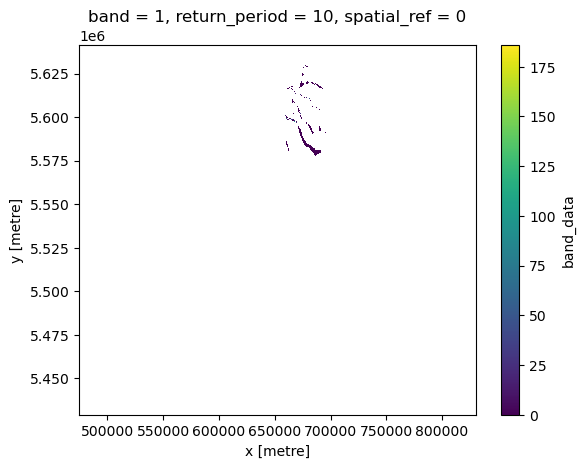

In [33]:
impact["CHE/CH-ZH"]["band_data"].sel(return_period=10).plot()

In [ ]:
with ce.dask_client(1, 2, "4GB"):
    ce.merge_tree_dset(impact["CHE"].sel(return_period=10))["band_data"].plot()

In [41]:
output = engine.aggregate(
    {
        "CHE": ce.at_event,
        "DEU": lambda x: ce.average_event_impact(
            x, event_dim="return_period", weights=1.0 / impact["/DEU"]["return_period"]
        ),
    }
).compute()
output

KeyboardInterrupt: 

## CLIMADA Equivalent

In [32]:
from climada.hazard import Hazard

ne_gdf = gpd.read_file(ne)
hazard = Hazard.from_raster(
    "data/hazard/Europe_RP100_filled_depth.tif",
    dst_crs="ESRI:54009",
    geometry=ne_gdf[ne_gdf["adm0_a3"].isin(["DEU", "CHE", "FRA"])].geometry,
)

: 

In [ ]:
from climada.entity import Exposures

exp = Exposures.from_raster(
    "data/exposure/GHS_POP_E2025_GLOBE_R2023A_54009_100_V1_0_R4_C19.tif"
)